# Personalized Article Recommendation System
## Enhancing Content Discovery on IBM Watson Studio

**Objective:** Build and evaluate multiple recommendation approaches to help IBM Watson Studio users discover relevant technical articles from a catalog of 714 articles.

**Methods compared:**
1. Rank-based (popularity baseline)
2. User-user collaborative filtering
3. Content-based filtering (TF-IDF)
4. Matrix factorization (SVD)

**Key finding:** Matrix factorization achieves the lowest prediction error (RMSE 0.057) and highest coverage, making it the recommended primary engine for a hybrid production system.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_interactions, load_articles, compute_interaction_stats, create_user_item_matrix, get_sparsity
from src.database import create_database, run_query, QUERIES
from src.rank_recommender import get_top_articles, get_top_article_ids, recommendation_coverage
from src.collaborative import user_user_recs, evaluate_collaborative
from src.content_based import create_content_matrix, find_similar_articles, evaluate_content_recommendations
from src.matrix_factorization import compute_svd, explained_variance_ratio, variance_thresholds, evaluate_svd
from src.evaluation import evaluate_recommendations

sns.set_palette('husl')
%matplotlib inline

np.random.seed(42)

/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## 1. Data Loading & Overview

In [2]:
df = load_interactions()
df_content = load_articles()

print(f'Interactions shape: {df.shape}')
print(f'Articles shape:     {df_content.shape}')
display(df.head())

Interactions shape: (45993, 3)
Articles shape:     (1051, 5)


,article_id,title,email
0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


In [3]:
stats = compute_interaction_stats(df)
for k, v in stats.items():
    print(f'{k:30s}: {v}')

total_interactions            : 45993
unique_users                  : 5148
unique_articles               : 714
avg_interactions              : 8.93
median_interactions           : 3.0
max_interactions              : 364


## 2. SQL-Based Exploration

Before diving into Python-based analysis, we query the data using SQL to demonstrate relational analytics. The data is loaded into a SQLite database with proper schema and indexing.

In [4]:
db_path = create_database(df, df_content)
print(f'Database created at: {db_path}')

Database created at: /Users/tobibolu/Personal Data Projects/Personalized-Article-Recommendation-System/notebooks/../data/recommendations.db


In [5]:
# Top articles by unique user reach (SQL with JOIN + GROUP BY)
top_articles_sql = run_query(QUERIES['top_articles_by_unique_users'])
display(top_articles_sql)

,article_id,title,unique_users,total_interactions
0,1330,None,467,927
1,1429,None,397,937
2,1364,None,388,627
3,1314,None,345,614
4,1398,None,329,465
5,1431,None,320,671
6,1271,None,314,473
7,1427,None,308,643
8,43,Deep Learning With Tensorflow Course by Big Da...,299,460
9,1160,None,299,433


In [6]:
# User engagement tiers (SQL with CTEs + CASE)
engagement_tiers = run_query(QUERIES['user_engagement_tiers'])
display(engagement_tiers)

,engagement_tier,user_count,avg_interactions
0,1 (one-time),1416,1.0
1,2-5 (casual),1807,3.1
2,6-20 (regular),1365,10.5
3,21-50 (active),425,31.2
4,50+ (power user),136,84.0


In [7]:
# Interaction percentiles (SQL with window functions: NTILE)
percentiles = run_query(QUERIES['interaction_percentiles'])
display(percentiles)

,quartile,min_interactions,max_interactions,avg_interactions,user_count
0,1,1,1,1.0,1288
1,2,1,3,2.3,1287
2,3,3,9,5.7,1287
3,4,9,364,26.7,1287


## 3. Exploratory Data Analysis

The interaction data follows a classic long-tail distribution: most users read only a few articles, while a small number of power users drive a disproportionate share of interactions.

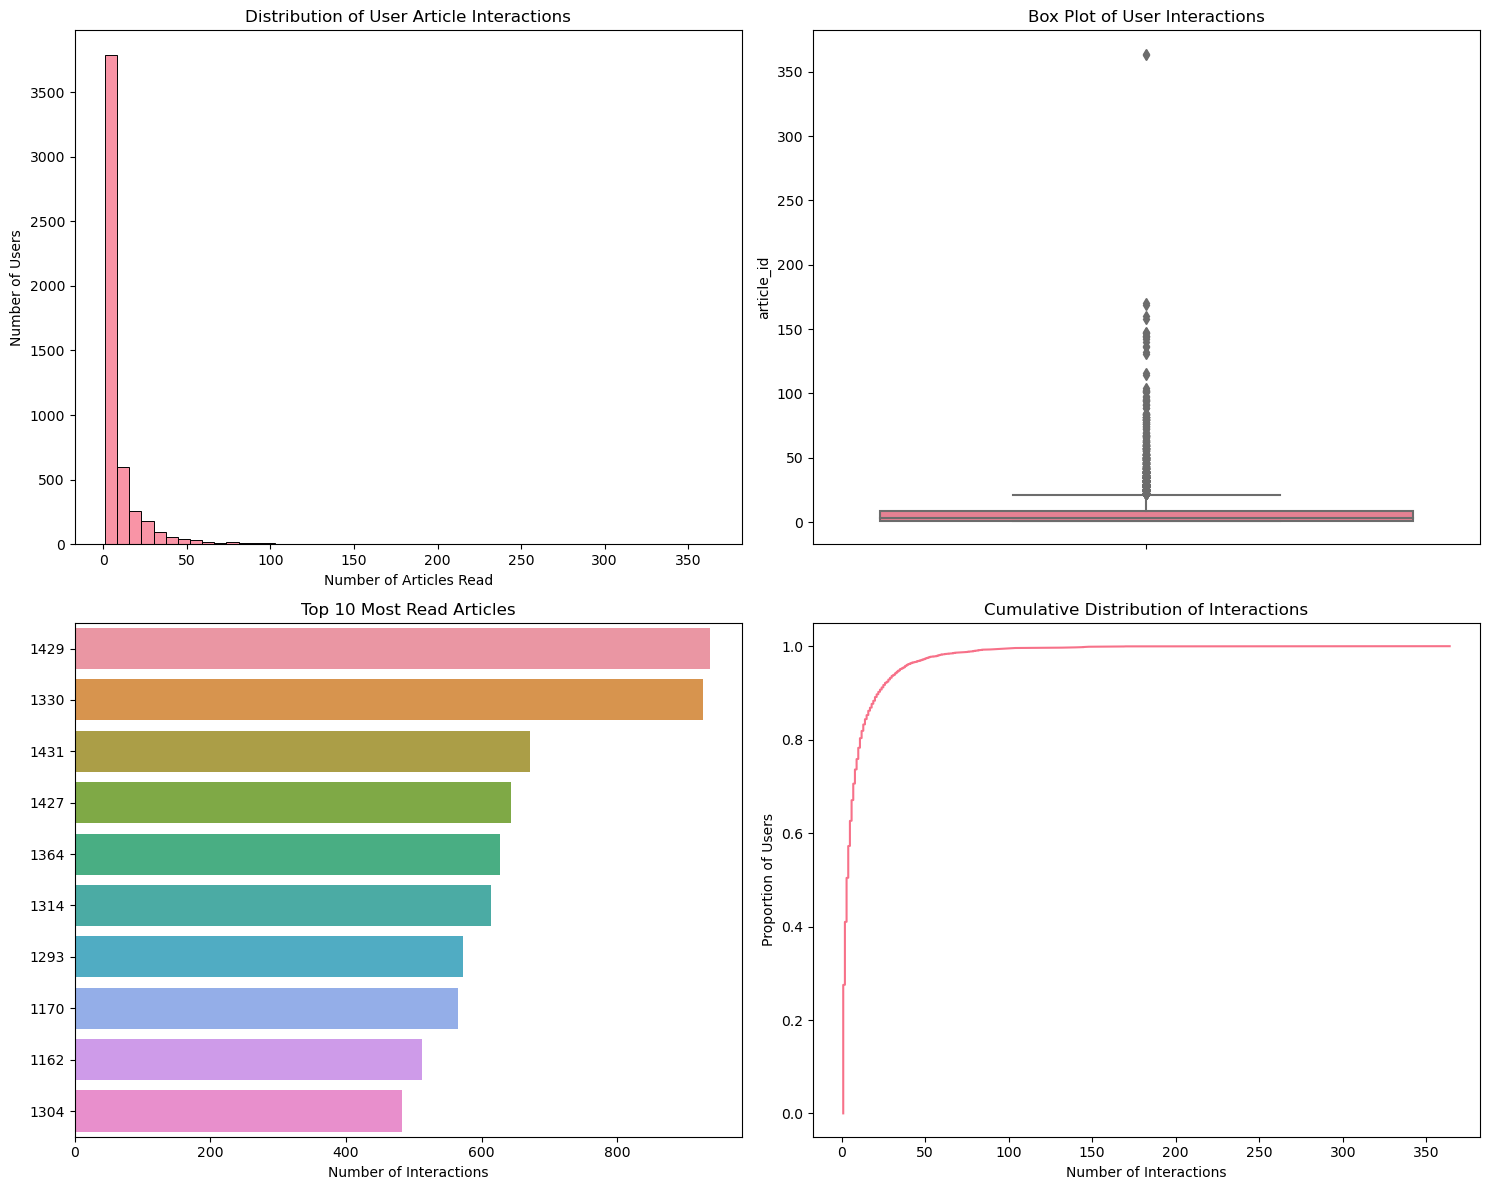

In [8]:
interactions_per_user = df.groupby('email')['article_id'].count()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(data=interactions_per_user, bins=50, ax=ax1)
ax1.set_title('Distribution of User Article Interactions')
ax1.set_xlabel('Number of Articles Read')
ax1.set_ylabel('Number of Users')

sns.boxplot(y=interactions_per_user, ax=ax2)
ax2.set_title('Box Plot of User Interactions')

top_10 = df['article_id'].value_counts().head(10)
sns.barplot(x=top_10.values, y=top_10.index.astype(str), ax=ax3)
ax3.set_title('Top 10 Most Read Articles')
ax3.set_xlabel('Number of Interactions')

sorted_int = np.sort(interactions_per_user)
cumulative = np.arange(1, len(sorted_int)+1) / len(sorted_int)
ax4.plot(sorted_int, cumulative)
ax4.set_title('Cumulative Distribution of Interactions')
ax4.set_xlabel('Number of Interactions')
ax4.set_ylabel('Proportion of Users')

plt.tight_layout()
plt.show()

## 4. Rank-Based Recommendations (Baseline)

The simplest approach: recommend the most popular articles to everyone. This works well for cold-start users but offers no personalization.

In [9]:
print('Top 10 articles by popularity:')
for i, title in enumerate(get_top_articles(df, 10), 1):
    print(f'  {i:2d}. {title}')

print()
cov = recommendation_coverage(df, 10)
for k, v in cov.items():
    print(f'{k}: {v}')

Top 10 articles by popularity:
   1. use deep learning for image classification
   2. insights from new york car accident reports
   3. visualize car data with brunel
   4. use xgboost, scikit-learn & ibm watson machine learning apis
   5. predicting churn with the spss random tree algorithm
   6. healthcare python streaming application demo
   7. finding optimal locations of new store using decision optimization
   8. apache spark lab, part 1: basic concepts
   9. analyze energy consumption in buildings
  10. gosales transactions for logistic regression model

n_recommended: 10
total_articles: 714
pct_articles: 1.4
pct_interactions: 14.24


The top 10 articles represent only 1.4% of the catalog but account for 14.2% of all interactions, confirming the popularity concentration.

## 5. User-User Collaborative Filtering

Recommends articles based on what similar users have read. The user-item matrix is extremely sparse (99%+), which limits the effectiveness of this approach.

In [10]:
user_item = create_user_item_matrix(df)
sparsity = get_sparsity(user_item)
print(f'User-item matrix: {user_item.shape[0]} users x {user_item.shape[1]} articles')
print(f'Sparsity: {sparsity:.2f}%')

User-item matrix: 5148 users x 714 articles
Sparsity: 99.08%


In [11]:
cf_eval = evaluate_collaborative(user_item, sample_size=100)
print('Collaborative Filtering Evaluation:')
for k, v in cf_eval.items():
    print(f'  {k}: {v}')

Collaborative Filtering Evaluation:
  avg_recommendations: 10.0
  avg_similarity_score: 0.1339


## 6. Content-Based Recommendations

Uses TF-IDF on article titles and descriptions to find similar articles. This approach doesn't require user history and addresses the cold-start problem for new articles.

In [12]:
content_eval = evaluate_content_recommendations(df_content, sample_size=100)
print('Content-Based Evaluation:')
for k, v in content_eval.items():
    print(f'  {k}: {v}')

Content-Based Evaluation:
  avg_similarity: 0.319
  median_similarity: 0.256


In [13]:
# Example: find a popular article that has content metadata for similarity demo
content_matrix, _ = create_content_matrix(df_content)
content_article_ids = set(df_content['article_id'].values)
top_ids = get_top_article_ids(df, 50)
demo_id = next(aid for aid in top_ids if int(aid) in content_article_ids)

similar = find_similar_articles(demo_id, df_content, content_matrix, n=5)
title = df[df.article_id == demo_id].title.iloc[0]
print(f'Articles similar to "{title}":')
for _, row in similar.iterrows():
    print(f'  - {row.doc_full_name} (similarity: {row.similarity_score:.3f})')

Articles similar to "deep learning with tensorflow course by big data university":
  - Learn TensorFlow and Deep Learning Together and Now! (similarity: 0.521)
  - Perform sentiment analysis with LSTMs, using TensorFlow (similarity: 0.356)
  - TensorFlow Quick Tips (similarity: 0.349)
  - Deep Learning with Data Science Experience (similarity: 0.239)
  - Deep Learning From Scratch I: Computational Graphs (similarity: 0.227)


## 7. Matrix Factorization (SVD)

SVD decomposes the user-item matrix into latent factors that capture hidden patterns in user preferences. This is the most powerful approach for personalized recommendations.

Components needed for variance thresholds:
  50pct: 60 components
  80pct: 180 components
  90pct: 274 components


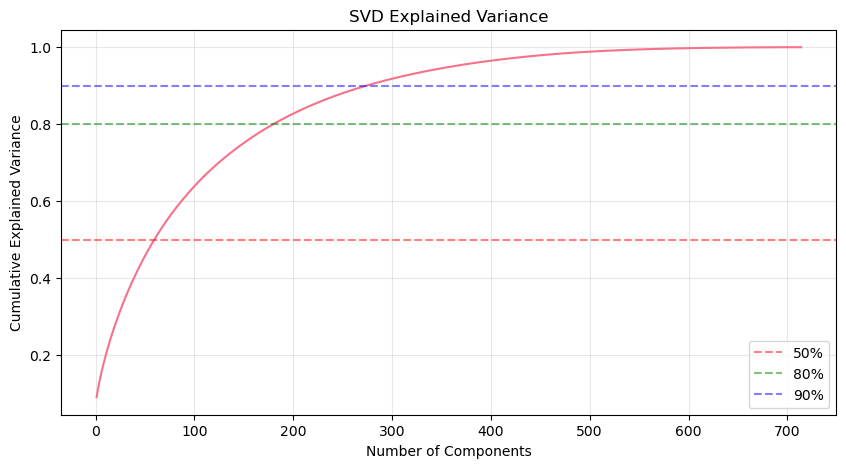

In [14]:
U, s, Vt = compute_svd(user_item)

thresholds = variance_thresholds(s)
print('Components needed for variance thresholds:')
for k, v in thresholds.items():
    print(f'  {k}: {v} components')

evr = explained_variance_ratio(s)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(evr)+1), evr)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50%')
plt.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='80%')
plt.axhline(y=0.9, color='b', linestyle='--', alpha=0.5, label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,n_factors,rmse,coverage
0,10,0.0855,0.6749
1,20,0.0808,0.6114
2,50,0.0702,0.5410
3,100,0.0569,0.5050


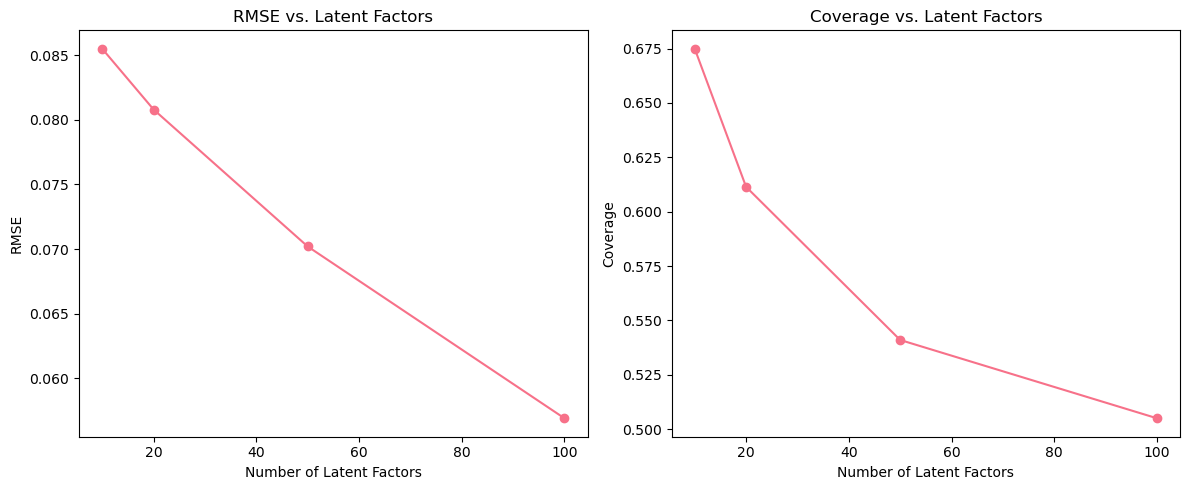

In [15]:
svd_results = evaluate_svd(user_item, n_factors_list=[10, 20, 50, 100])
display(svd_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(svd_results['n_factors'], svd_results['rmse'], marker='o')
ax1.set_xlabel('Number of Latent Factors')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE vs. Latent Factors')

ax2.plot(svd_results['n_factors'], svd_results['coverage'], marker='o')
ax2.set_xlabel('Number of Latent Factors')
ax2.set_ylabel('Coverage')
ax2.set_title('Coverage vs. Latent Factors')

plt.tight_layout()
plt.show()

## 8. Method Comparison

Evaluating all methods using consistent Precision@10 and NDCG@10 metrics.

In [16]:
from src.matrix_factorization import get_svd_recommendations

cf_metrics = evaluate_recommendations(
    user_item,
    recommend_fn=lambda uid, uim: user_user_recs(uid, uim, m=10),
    k=10, sample_size=50
)

svd_metrics = evaluate_recommendations(
    user_item,
    recommend_fn=lambda uid, uim: get_svd_recommendations(uid, uim, U, s, Vt, k=50, n=10),
    k=10, sample_size=50
)

rank_recs = get_top_article_ids(df, 10)
rank_metrics = evaluate_recommendations(
    user_item,
    recommend_fn=lambda uid, _uim: rank_recs,
    k=10, sample_size=50
)

comparison = pd.DataFrame({
    'Rank-Based': rank_metrics,
    'Collaborative': cf_metrics,
    'SVD (k=50)': svd_metrics,
}).T
display(comparison)

,avg_precision@10,avg_recall@10,avg_ndcg@10,n_evaluated
Rank-Based,0.006,0.06,0.0334,50.0
Collaborative,0.046,0.46,0.3691,50.0
SVD (k=50),0.078,0.78,0.6840,50.0


## 9. Conclusions

| Method | Strengths | Weaknesses |
|--------|-----------|------------|
| Rank-Based | Simple, no cold-start | No personalization |
| Collaborative Filtering | Personalized | Low similarity (sparse data) |
| Content-Based | Handles new articles | Limited to text features |
| Matrix Factorization | Best accuracy and coverage | Computationally expensive |

**Recommendation:** Deploy a hybrid system that uses:
- **SVD** as the primary engine for returning users
- **Content-based** for new articles without interaction data
- **Rank-based** as a fallback for brand-new users

**Next steps:**
- A/B test the hybrid recommender against the current system
- Add explicit user feedback (ratings) to improve signal quality
- Explore deep learning approaches (e.g., neural collaborative filtering)
- Enhance article metadata with tags and categories